# START HERE

See Constants.py for the coin you want to analyze. Enter the crypto coin sign

1. Get the Latest Price Data

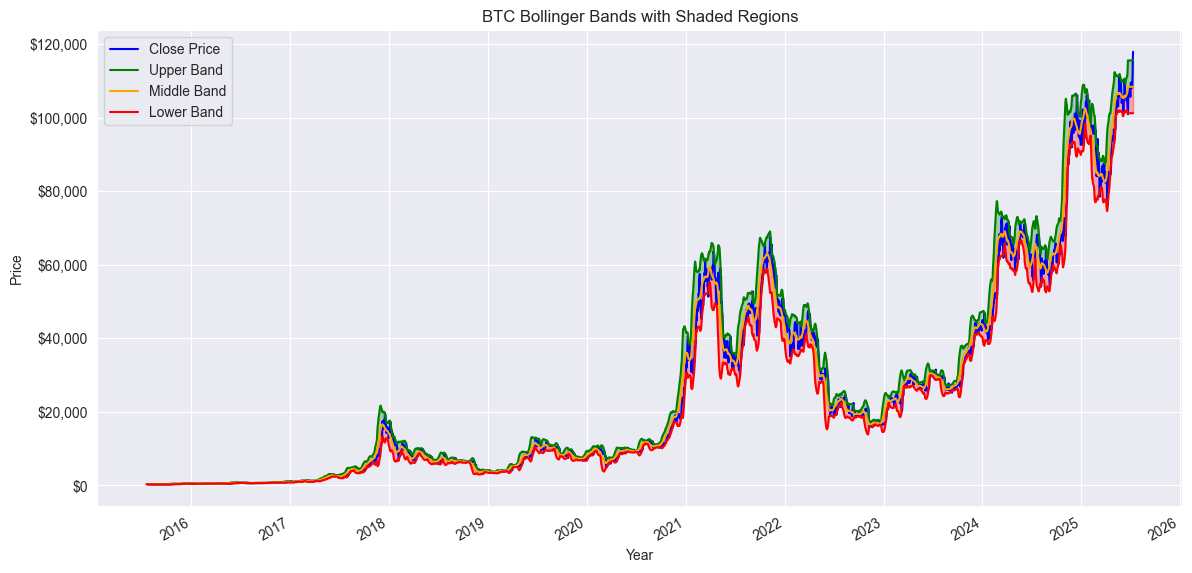

In [1]:
import pandas as pd
import numpy as np
import CONSTANTS
from functions import *
import warnings
warnings.filterwarnings('ignore')

%run CoinbaseMarketAnalysisGradient.ipynb

2. Get Newspapers & Sentiment

Note: can take over 20 minutes to run based on how many queries are in the file

DO NOT RUN BY ITSELF

In [2]:
cn = newspaper_sentiment_pipeline(COIN, newspaper_path=f'newspapers/{COIN}_newspapers.csv', queries_path='queries.txt')
cn

,time,low,high,open,close,volume,change,pct_change,timestamp,value,...,position,title,source,link,thumbnail,thumbnail_small,date,text,score,sentiment
0,2025-07-11,115211.74,118909.74,116031.29,118005.24,9195.139228,1973.95,1.701222,1970-01-01,58.0,...,0.0,-,-,-,-,-,NaT,-,0.000000,-
1,2025-07-10,110541.87,116842.00,111282.84,116031.30,12920.207429,4748.46,4.267019,2025-07-10,58.0,...,1.0,Bitcoin touches another fresh all-time high ab...,"{'name': 'Business Insider', 'icon': 'https://...",https://www.businessinsider.com/bitcoin-price-...,https://i.insider.com/6841d196c19ab3675c10bae4...,https://news.google.com/api/attachments/CC8iK0...,2025-07-10,Bitcoin just broke through its second all-time...,2.249770,neutral
2,2025-07-10,110541.87,116842.00,111282.84,116031.30,12920.207429,4748.46,4.267019,2025-07-10,58.0,...,2.0,"Bitcoin price hits record high of $112,000","{'name': 'Yahoo', 'icon': 'https://encrypted-t...",https://uk.finance.yahoo.com/news/bitcoin-pric...,https://s.yimg.com/ny/api/res/1.2/KtaYUkh_r4Qa...,https://news.google.com/api/attachments/CC8iK0...,2025-07-10,"Bitcoin price hits record high of $112,000",-0.000158,neutral
3,2025-07-10,110541.87,116842.00,111282.84,116031.30,12920.207429,4748.46,4.267019,2025-07-10,58.0,...,3.0,Bitcoin: Price Breaks Out Of Consolidation And...,"{'name': 'Seeking Alpha', 'icon': 'https://enc...",https://seekingalpha.com/article/4800418-bitco...,https://static.seekingalpha.com/cdn/s3/uploads...,https://news.google.com/api/attachments/CC8iK0...,2025-07-10,BlackJack3D\n \nBlackJack3D\nBy Sholanke D...,0.000499,neutral
4,2025-07-10,110541.87,116842.00,111282.84,116031.30,12920.207429,4748.46,4.267019,2025-07-10,58.0,...,4.0,Bitcoin Price Levels to Watch After Cryptocurr...,"{'name': 'Investopedia', 'icon': 'https://encr...",https://www.investopedia.com/bitcoin-price-lev...,-,-,2025-07-10,"Bitcoin (BTCUSD) powered past $112,000 to ano...",0.015005,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4324,2015-07-24,276.43,291.52,277.23,289.12,7362.469083,11.89,4.288858,1970-01-01,58.0,...,0.0,-,-,-,-,-,NaT,-,0.000000,-
4325,2015-07-23,276.28,279.75,277.96,277.39,5306.919575,-0.57,-0.205065,1970-01-01,58.0,...,0.0,-,-,-,-,-,NaT,-,0.000000,-
4326,2015-07-22,275.01,278.54,277.33,277.89,4687.909383,0.56,0.201926,1970-01-01,58.0,...,0.0,-,-,-,-,-,NaT,-,0.000000,-
4327,2015-07-21,276.85,281.27,279.96,277.32,4943.559434,-2.64,-0.942992,1970-01-01,58.0,...,0.0,-,-,-,-,-,NaT,-,0.000000,-


# Do machine learning

## Hyperparameter Tuning

In [ ]:
class MLWrapper:
    def __init__(self, model, X_train, y_train, X_test, y_test):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

    def fit(self):
        self.model.fit(self.X_train, self.y_train)

    def predict(self):
        return self.model.predict(self.X_test)
    
    def hyperparameter_tuning(self, X, y, param_grid=None, cv=5):
        self.model.tune_hyperparameters(param_grid, X, y, cv=cv)
        self.model.fit(**self.model.best_params_)